In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import nnls
import matplotlib.pyplot as plt
import itertools
rng = np.random.default_rng(seed=None)

In [2]:
def generate_mixture_spectra(
    df,
    wavelength_col="Wavelength",
    combination_sizes=(2, 3),
    n_mixtures_per_combination=5,
    random_state=42
):
    """
    df: DataFrame with one wavelength column and one column per pure spectrum.
        Example columns: ['Wavelength', 'Diatom_Ptricornutum', ...]
    wavelength_col: name of the wavelength column.
    combination_sizes: tuple with sizes of combinations (e.g. (1, 2, 3, 4)).
        - 1 means single-species "mixtures" (i.e. just that pure spectrum again).
    n_mixtures_per_combination: number of random weightings per given combination.
    random_state: seed for reproducibility.

    Returns:
        mixtures_df: DataFrame with:
            - the wavelength column
            - one column per pure spectrum (copied from df)
            - additional columns for artificial mixtures
        weights_df: DataFrame that stores the weights used for each mixture column
            (so you know the exact composition).
    """
    rng = np.random.default_rng(random_state)

    # All species columns
    spectrum_cols = [c for c in df.columns if c != wavelength_col]

    # To store composition (weights) for each mixture column
    weights_records = []

    new_mixtures_dict = {}

    for k in combination_sizes:
        # All k-element combinations of the spectrum columns
        for comb in itertools.combinations(spectrum_cols, k):
            comb_name_base = "_".join(comb)

            for m in range(n_mixtures_per_combination):
                # Random non-negative weights that sum to 1
                weights = rng.dirichlet(np.ones(k))

                # Linear combination: mix = sum_i w_i * spectrum_i
                mix_spectrum = np.zeros(len(df))
                for col, w in zip(comb, weights):
                    mix_spectrum += w * df[col].values

                # Unique column name for this mixture
                mix_col_name = f"mix{k}_{comb_name_base}_{m}"

                new_mixtures_dict[mix_col_name] = mix_spectrum

                # Store the weights and which species were used
                record = {"mixture_name": mix_col_name}
                for col, w in zip(comb, weights):
                    record[col] = w
                weights_records.append(record)

    new_mixtures_df = pd.DataFrame(new_mixtures_dict)
    mixtures_df = pd.concat([df, new_mixtures_df], axis=1)

    weights_df = pd.DataFrame(weights_records).fillna(0.0)

    return mixtures_df, weights_df

In [3]:
df = pd.read_excel('Spectral_library_clean.xlsx')
df.ffill(axis=0, inplace=True)
df.bfill(axis=0, inplace=True)  # handles leading NaNs

# if there is a NaN, interpolate data linearly

wavelength = df['Wavelength']
abs_spectra = df.iloc[:, 1:].to_numpy().T
mixture, weights = generate_mixture_spectra(df, combination_sizes=(8,9), n_mixtures_per_combination=100)
mixture, weights = mixture.to_numpy(), weights.to_numpy()
mixture, weights = mixture[:,10:], weights[:,1:]

In [4]:
print(mixture.shape)
print(abs_spectra.T.shape)
print(weights.shape)

(451, 1000)
(451, 9)
(1000, 9)


In [5]:
noise = rng.normal(0, 1, size = mixture.shape)
mixture_noisy = mixture + 0.01 * noise
print(abs_spectra.T.shape)
print(mixture_noisy.shape)

(451, 9)
(451, 1000)


In [6]:
estimated_conc = np.array([nnls(abs_spectra.T, mixture_noisy[:, i])[0] for i in range(mixture_noisy.shape[1])])

/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - MSc AMEP/Semester 2/Machine Learning/.venv/lib/python3.9/site-packages/scipy/optimize/_nnls.py:106: RuntimeWarning: divide by zero encountered in matmul
  Atb = b @ A  # Result is 1D - let NumPy figure it out
/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - MSc AMEP/Semester 2/Machine Learning/.venv/lib/python3.9/site-packages/scipy/optimize/_nnls.py:106: RuntimeWarning: overflow encountered in matmul
  Atb = b @ A  # Result is 1D - let NumPy figure it out
/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - MSc AMEP/Semester 2/Machine Learning/.venv/lib/python3.9/site-packages/scipy/optimize/_nnls.py:106: RuntimeWarning: invalid value encountered in matmul
  Atb = b @ A  # Result is 1D - let NumPy figure it out
/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - MSc AMEP/Semester 2/Machine Learning/.venv/lib/python3.9/site-packages/scipy/optimize/_nnls.py:164: RuntimeWarning: divide by zero encou

In [29]:
# print(estimated_conc.shape)
# print(weights.shape)
# print(estimated_conc[0,:], weights[0,:])
estimated_conc = np.array(estimated_conc, dtype=float)
weights = np.array(weights, dtype=float)
difference = np.abs(estimated_conc - weights)
mean_accuracy_per_mixture = np.mean(difference, axis =1)
std_accuracy_per_mixture = np.std(difference, axis = 1)
print(std_accuracy_per_mixture.shape)
print(mean_accuracy_per_mixture.shape)
print(mean_accuracy_per_mixture[0], std_accuracy_per_mixture[0])

(1000,)
(1000,)
0.05311787092163261 0.10855888540023356


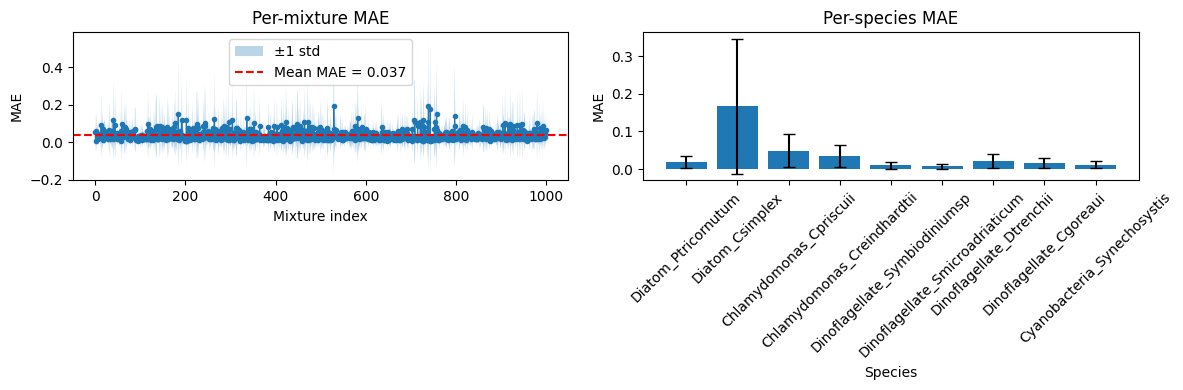

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mean_accuracy_per_mixture, marker='o', markersize=3, linewidth=0.8)
axes[0].fill_between(
    range(len(mean_accuracy_per_mixture)),
    mean_accuracy_per_mixture - std_accuracy_per_mixture,
    mean_accuracy_per_mixture + std_accuracy_per_mixture,
    alpha=0.3, label='±1 std'
)
axes[0].axhline(np.mean(mean_accuracy_per_mixture), color='red', linestyle='--', label=f'Mean MAE = {np.mean(mean_accuracy_per_mixture):.3f}')
axes[0].set_xlabel("Mixture index")
axes[0].set_ylabel("MAE")
axes[0].set_title("Per-mixture MAE")
axes[0].legend()


species_names = df.columns[1:].tolist()   # adjust if needed
per_species_mae = np.mean(difference, axis=0)
per_species_std = np.std(difference, axis=0)

axes[1].bar(species_names, per_species_mae, yerr=per_species_std, capsize=4)
axes[1].set_xlabel("Species")
axes[1].set_ylabel("MAE")
axes[1].set_title("Per-species MAE")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()